In [1]:
import cme.decision_models.confidence_accumulation as ca
import numpy as np
import jax
import numpyro as npy
import numpyro.distributions as dist
import pandas as pd
import seaborn as sns

In [2]:
rng = jax.random.key(1)

In [3]:
dist.Beta(2,2).sample(rng, sample_shape=(100,10))

Array([[0.28618392, 0.95923012, 0.86018887, 0.25604541, 0.61924089,
        0.69670141, 0.53527126, 0.47488095, 0.61453233, 0.30014722],
       [0.73452404, 0.48042446, 0.40741151, 0.41449278, 0.77711294,
        0.80638017, 0.8151334 , 0.30968146, 0.35727852, 0.21708799],
       [0.45747685, 0.54685923, 0.75201615, 0.73163743, 0.19835198,
        0.54543592, 0.6912994 , 0.88790162, 0.47049677, 0.61090318],
       [0.98847781, 0.57244385, 0.20195492, 0.44246813, 0.2917631 ,
        0.39975486, 0.52796825, 0.50718907, 0.96677851, 0.17357482],
       [0.67459765, 0.20468939, 0.50078226, 0.7436662 , 0.56925032,
        0.50422085, 0.7733076 , 0.7818718 , 0.42030821, 0.40599751],
       [0.75196811, 0.16971339, 0.41910483, 0.458086  , 0.73360909,
        0.28855816, 0.66583538, 0.5529878 , 0.85498264, 0.59082725],
       [0.29235935, 0.54112585, 0.73817122, 0.4417063 , 0.15257548,
        0.75132184, 0.98832989, 0.36154938, 0.38165597, 0.69361759],
       [0.14289616, 0.48994811, 0.4144184

In [17]:
n_states, start_width, threshold, delta, measurement_prob, mu, sigma, I, J = 7, 3, 2, 1, 0.8, np.asarray([[2]]), np.asarray([[1]]), 100, 50
model_type = "Markov"


In [18]:
Mc, Mw, Mn = ca._get_measurement_matrix(n_states, threshold, prob=measurement_prob, model_type = model_type)
Mc

Array([[0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0.8, 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0.8]], dtype=float64)

In [19]:
intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
phi_0 = ca._get_initial_state(n_states, start_width,model_type=model_type, prior_type="Uniform")
intensity_matrix, phi_0

(Array([[[[-1. , -0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
          [ 1. , -1. , -0.5,  0. ,  0. ,  0. ,  0. ],
          [ 0. ,  1.5, -1. , -0.5,  0. ,  0. ,  0. ],
          [ 0. ,  0. ,  1.5, -1. , -0.5,  0. ,  0. ],
          [ 0. ,  0. ,  0. ,  1.5, -1. , -0.5,  0. ],
          [ 0. ,  0. ,  0. ,  0. ,  1.5, -1. ,  1. ],
          [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -1. ]]]], dtype=float64),
 Array([[[[0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714]]]], dtype=float64))

In [20]:
t = np.asarray([[0.5]])
phi_t = ca.perform_state_transition(intensity_matrix=intensity_matrix, RT_s=t, RA_s = None, delta=delta, 
Mc = Mc, Mn = Mn, Mw = Mw, phi_0=phi_0, 
transition_type="TIMESTEP", likelihood_type="SINGLE")
phi_t

Array([[[[0.02416382],
         [0.0525951 ],
         [0.09427324],
         [0.12757936],
         [0.10502814],
         [0.31015873],
         [0.28620161]]]], dtype=float64)

In [21]:
S = np.where(dist.MultinomialProbs(phi_t.squeeze()).sample(rng))[0][0]
S

5

In [22]:
rt = []
ra = []
if S < start_width:
    rt.append(t)
    ra.append(0)
elif S > n_states - start_width:
    rt.append(t)
    ra.append(1)

rt, ra

([array([[0.5]])], [1])

In [23]:
def sample_state_1(phi):
    return np.where(dist.MultinomialProbs(phi_t).sample(rng))[0][0] + 1

def sample_state(phi):
    phi_cumsum = np.cumsum(phi)
    ran_prob = dist.Uniform().sample(rng)
    S = np.argmax(ran_prob < phi_cumsum)
    return S + 1 # due to 0-based indexing


def random_walk(intensity_matrix, phi_0, delta, T):
    ra = -1
    rt = -1
    states = []
    phi_arr = []
    for t in np.arange(delta, T, delta):
        phi_t = ca.perform_state_transition(intensity_matrix=intensity_matrix, RT_s=np.asarray([[t]]), RA_s = None, delta=delta, 
                                            Mc = Mc, Mn = Mn, Mw = Mw, phi_0=phi_0, 
                                            transition_type="TIMESTEP", likelihood_type="SINGLE")
        if model_type == "Quantum":
            phi_t = np.abs(phi_t)**2
        phi_t = phi_t.squeeze()/phi_t.sum()
        S = sample_state(phi_t) # adding 1 because where returns 0-based indexing
        #print(S)
        states.append(S)
        phi_arr.append(phi_t)
        if S < threshold:
            ra=0
            rt=t
            break
        elif S > n_states - threshold:
            ra=1
            rt=t
            break
    return rt, ra, states, phi_arr

In [24]:
phi = phi_t
phi_cumsum = np.cumsum(phi)
ran_prob = dist.Uniform().sample(rng)
S = np.argmax(ran_prob < phi_cumsum)
phi_cumsum, ran_prob, S

(Array([0.02416382, 0.07675892, 0.17103216, 0.29861152, 0.40363966,
        0.71379839, 1.        ], dtype=float64),
 Array(0.45375874, dtype=float64),
 Array(5, dtype=int64))

In [25]:
rt_s = []
ra_s = []
for _ in range(10):
    t, ra, states, phi_arr = random_walk(intensity_matrix, phi_0, 0.1, 100)
    rt_s.append(t)
    ra_s.append(ra)

In [26]:
rt_s

[23.800000000000004,
 23.800000000000004,
 23.800000000000004,
 23.800000000000004,
 23.800000000000004,
 23.800000000000004,
 23.800000000000004,
 23.800000000000004,
 23.800000000000004,
 23.800000000000004]

In [27]:
df_phi = pd.DataFrame(np.asarray(phi_arr), columns=np.arange(1,n_states+1))
df_phi

,1,2,3,4,5,6,7
0,0.122649,0.135072,0.142307,0.142839,0.142349,0.163608,0.151176
1,0.038890,0.037358,0.231262,0.260935,0.271335,0.098349,0.061872
2,0.002001,-0.012019,0.222208,0.323502,0.384886,0.069178,0.010242
3,0.002001,-0.012019,0.222208,0.323502,0.384886,0.069178,0.010242
4,0.000757,-0.012480,0.195968,0.321041,0.414004,0.072415,0.008295
...,...,...,...,...,...,...,...
233,0.000155,-0.005963,0.139110,-1.220360,1.698324,0.347676,0.041057
234,0.000789,-0.024757,0.483257,-2.394744,2.373718,0.501374,0.060363
235,0.000789,-0.024757,0.483257,-2.394744,2.373718,0.501374,0.060363
236,0.004506,-0.133203,2.432558,-8.169765,5.494820,1.219877,0.151206


In [28]:
states

[Array(4, dtype=int64),
 Array(4, dtype=int64),
 Array(4, dtype=int64),
 Array(4, dtype=int64),
 Array(4, dtype=int64),
 Array(4, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(5, dtype=int64),
 Array(3, dtype=int64),
 Array(3, dtype=int64),
 Array(3, dtype=int64),
 Array(3, dtype=int64),
 Array(3, dtype=int64),
 Array(3, dtype=int64),
 Array(3, dtype=int64),
 Array(3, dtype=int64),
 Array(3, dtype=

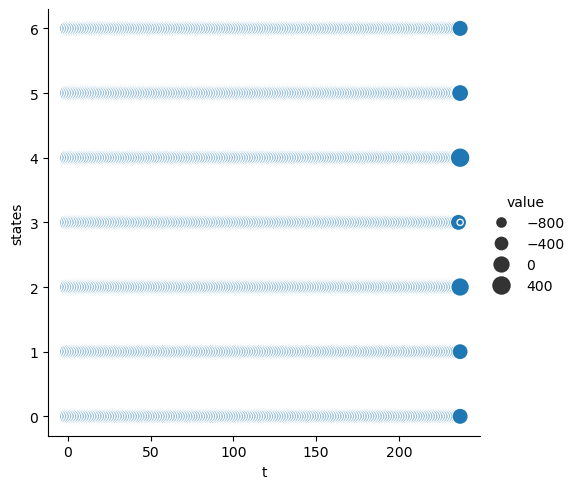

In [29]:
sns.relplot(pd.DataFrame(np.asarray(phi_arr)).reset_index(names="t").melt(id_vars = "t", var_name="states"),
x="t",
y="states",
size="value", sizes=(20, 200))